# 04_lstm_experiment_1

Goals:
- load sequence arrays
- build a baseline LSTM model in PyTorch
- train the model for RUL prediction
- evaluate the model on the test set
- visualize training behavior and predictions
- save the trained model and prediction results

In [38]:
import sys
from pathlib import Path

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split

In [ ]:
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
MODELS_DIR = PROJECT_DIR / "models"
RESULTS_DIR = PROJECT_DIR / "results"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
EXPERIMENT_NAME = "lstm_baseline_seq30_cap125"
print("Running experiment:", EXPERIMENT_NAME)

Running experiment: lstm_baseline_seq20_cap125


In [40]:
X_train = np.load(PROCESSED_DIR / "X_train.npy")
y_train = np.load(PROCESSED_DIR / "y_train.npy")
X_test = np.load(PROCESSED_DIR / "X_test.npy")
y_test = np.load(PROCESSED_DIR / "y_test.npy")

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (18731, 20, 15)
y_train shape: (18731,)
X_test shape: (100, 20, 15)
y_test shape: (100,)


In [41]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [42]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

print("X_train tensor shape:", X_train_tensor.shape)
print("y_train tensor shape:", y_train_tensor.shape)

X_train tensor shape: torch.Size([18731, 20, 15])
y_train tensor shape: torch.Size([18731, 1])


In [43]:
dataset = TensorDataset(X_train_tensor, y_train_tensor)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(9)
)

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 235
Validation batches: 59
Test batches: 2


In [44]:
class LSTMRULModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1, dropout=0.0):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.regressor = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        lstm_out, (hidden, cell) = self.lstm(x)

        last_hidden = hidden[-1]
        output = self.regressor(last_hidden)

        return output

In [45]:
input_size = X_train.shape[2]

model = LSTMRULModel(
    input_size=input_size,
    hidden_size=128,
    num_layers=2,
    dropout=0.2
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)

LSTMRULModel(
  (lstm): LSTM(15, 128, num_layers=2, batch_first=True, dropout=0.2)
  (regressor): Sequential(
    (0): Linear(in_features=128, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [46]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)

            running_loss += loss.item() * X_batch.size(0)

            all_preds.append(predictions.cpu().numpy())
            all_targets.append(y_batch.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    all_preds = np.vstack(all_preds).flatten()
    all_targets = np.vstack(all_targets).flatten()

    return epoch_loss, all_preds, all_targets

In [47]:
EPOCHS = 20

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_model_path = MODELS_DIR / f"{EXPERIMENT_NAME}.pt"

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, _, _ = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

print("Best validation loss:", best_val_loss)
print("Best model saved to:", best_model_path)

Epoch 01/20 | Train Loss: 3928.0882 | Val Loss: 1802.0832
Epoch 02/20 | Train Loss: 1738.7288 | Val Loss: 1801.3025
Epoch 03/20 | Train Loss: 1738.5972 | Val Loss: 1801.6531
Epoch 04/20 | Train Loss: 1739.1660 | Val Loss: 1803.4873
Epoch 05/20 | Train Loss: 1739.4570 | Val Loss: 1801.2987
Epoch 06/20 | Train Loss: 1740.1291 | Val Loss: 1802.2740
Epoch 07/20 | Train Loss: 1739.8634 | Val Loss: 1801.5969
Epoch 08/20 | Train Loss: 1739.6290 | Val Loss: 1801.3739
Epoch 09/20 | Train Loss: 1739.0095 | Val Loss: 1801.2467
Epoch 10/20 | Train Loss: 1656.8264 | Val Loss: 559.3156
Epoch 11/20 | Train Loss: 437.5424 | Val Loss: 367.6213
Epoch 12/20 | Train Loss: 341.1468 | Val Loss: 286.0557
Epoch 13/20 | Train Loss: 301.4636 | Val Loss: 286.3700
Epoch 14/20 | Train Loss: 278.7671 | Val Loss: 243.0357
Epoch 15/20 | Train Loss: 276.9156 | Val Loss: 232.4850
Epoch 16/20 | Train Loss: 267.5701 | Val Loss: 236.3962
Epoch 17/20 | Train Loss: 263.6395 | Val Loss: 238.4687
Epoch 18/20 | Train Loss: 252

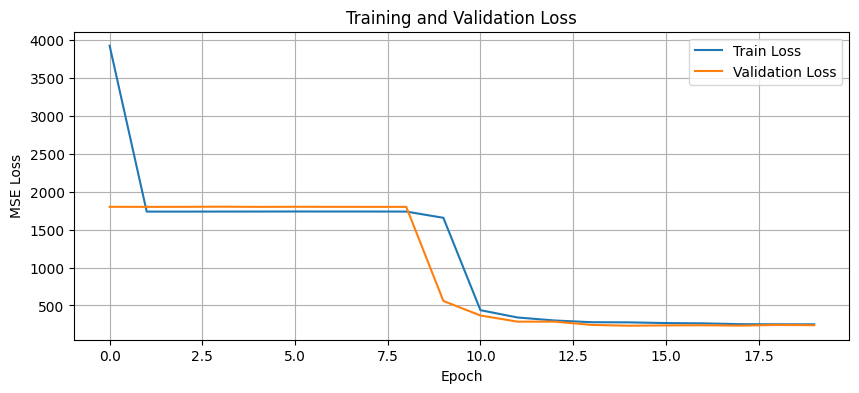

In [48]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [49]:
model.load_state_dict(torch.load(best_model_path, map_location=device))

test_loss, y_pred, y_true = evaluate(model, test_loader, criterion, device)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("Test Loss (MSE):", test_loss)
print("Test RMSE:", rmse)
print("Test MAE:", mae)
print("Test R2:", r2)

Test Loss (MSE): 296.6732336425781
Test RMSE: 17.224204416269494
Test MAE: 12.465149879455566
Test R2: 0.8282017111778259


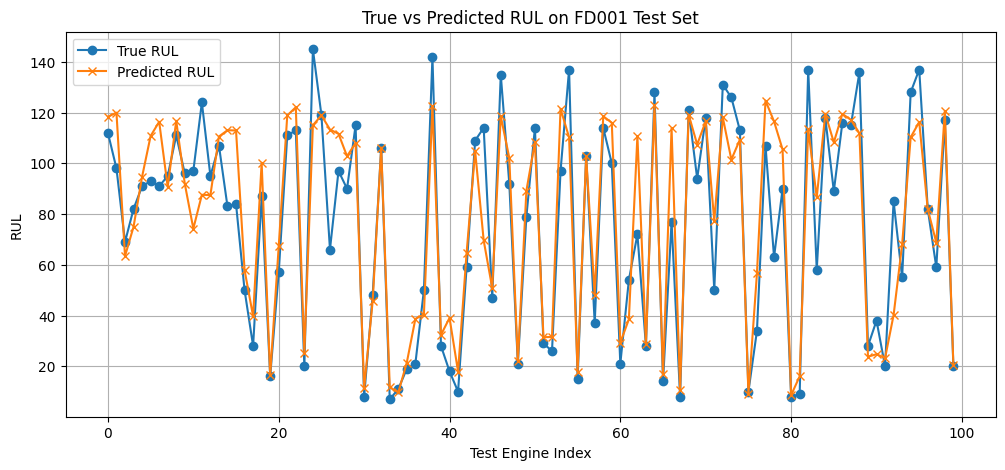

In [50]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="True RUL", marker="o")
plt.plot(y_pred, label="Predicted RUL", marker="x")
plt.xlabel("Test Engine Index")
plt.ylabel("RUL")
plt.title("True vs Predicted RUL on FD001 Test Set")
plt.legend()
plt.grid(True)
plt.show()

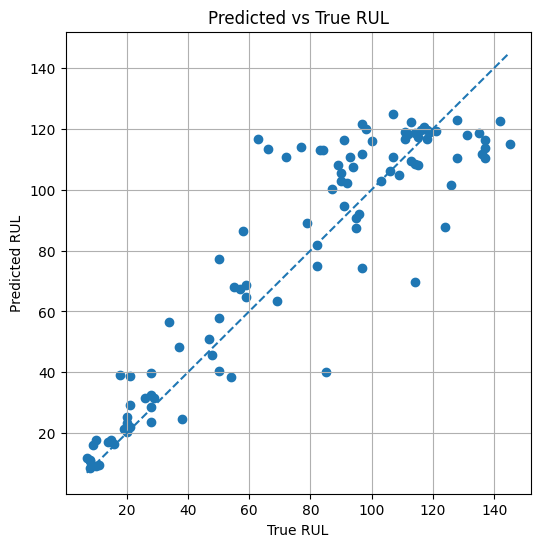

In [51]:
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred)

min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("Predicted vs True RUL")
plt.grid(True)
plt.show()

In [52]:
results_df = pd.DataFrame({
    "true_rul": y_true,
    "predicted_rul": y_pred
})

results_path = RESULTS_DIR / f"{EXPERIMENT_NAME}_predictions.csv"
results_df.to_csv(results_path, index=False)

print("Predictions saved to:", results_path)
results_df.head()

Predictions saved to: /home/flaviu/licenta/results/lstm_baseline_seq20_cap125_predictions.csv


,true_rul,predicted_rul
0,112.0,118.392586
1,98.0,119.981865
2,69.0,63.417725
3,82.0,74.977669
4,91.0,94.738022


In [53]:
def nasa_score(y_true, y_pred):
    errors = y_pred - y_true
    score = 0

    for e in errors:
        if e < 0:
            score += np.exp(-e / 13) - 1
        else:
            score += np.exp(e / 10) - 1

    return score

In [54]:
score = nasa_score(y_true, y_pred)
print("NASA score:", score)

NASA score: 732.1565


In [ ]:
summary_path = RESULTS_DIR / "experiment_metrics_summary.csv"

new_row = pd.DataFrame([{
    "experiment": EXPERIMENT_NAME,
    "sequence_length":X_train.shape[1],
    "rul_cap": 125,
    "features": X_train.shape[2],
    "rmse": rmse,
    "mae": mae,
    "r2": r2,
    "nasa_score": score
}])

if summary_path.exists():
    old_df = pd.read_csv(summary_path)
    
   
    old_df = old_df[old_df["experiment"] != EXPERIMENT_NAME]
    
    summary_df = pd.concat([old_df, new_row], ignore_index=True)
else:
    summary_df = new_row

summary_df.to_csv(summary_path, index=False)

summary_df

,experiment,sequence_length,rul_cap,features,rmse,mae,r2,nasa_score
0,lstm_2layer_h128_dropout02_seq30_cap125,30,125,15,14.933655,10.971383,0.870856,407.173920
1,lstm_baseline_seq30_cap125,30,125,15,15.014284,11.450275,0.869458,405.800201
2,lstm_baseline_seq50_cap125,50,125,15,17.980077,12.138040,0.812792,891.001404
3,lstm_baseline_seq20_cap125,20,125,15,17.224204,12.465150,0.828202,732.156494
